<a href="https://colab.research.google.com/github/hyperdbio/Android-inject/blob/master/ex02_%EC%9D%B4%EC%A7%84%EB%B6%84%EB%A5%98(%EB%B3%B5%EC%8A%B5)_%EC%9C%A0%EB%B0%A9%EC%95%94%EB%8D%B0%EC%9D%B4%ED%84%B0%EC%98%88%EC%B8%A1%EC%8B%A4%EC%8A%B5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 목표
- 환자 데이터를 바탕으로 유방암 여부를 판단하자
- 딥러닝 신경망을 통해서 이진 분류를 진행하자
- sklearn.datasets에서 제공하는 load_breast_cancer를 이용하자


In [ ]:
# 2d - 연산량이 그렇게 까지 많지 않음 -> cpu
# 드라이브, 경로 이동 (%cd) -> 실습 데이터는 mydrive에 없기때문에 연동 X

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer

In [ ]:
# data 살펴보기
# {key:array([[]]), key:array([])}
# 딕셔너리 형태, 딕셔너리 형태로 다루기 가능
# dic[key]
# sklearn.datasets -> 데이터 묶음, 데이터의 다발 -> bunch객체
# 추후에 iris (붓꽃 품종 분류) 데이터 사용할 예정 -> bunch객체
data = load_breast_cancer()
data.keys()


dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])

In [ ]:
# data 특성 데이터 - array(컬럼명이 지정되지 않음)
# target 정답 데이터 ( label )
# feature_names 특성 이름(컬럼명)
# target_names label 실제 이름(설명되는 문자열)
# DESCR describe 데이터 설명(기술통계량, 상관관계, 데이터 타입, 크기, 출처 등)


In [ ]:
# 데이터 확인 - 문제 , 특성
# dict['key']
# dict.key
data['data']

dict['data_module']



dict['data_module']

In [ ]:
# 특성의 이름 확인해보기
data['feature_names']

array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [ ]:
# target 살펴보기
data['target']

# 데이터 섞여 있음
# 0, 1 : 클래스가 2개 (이진분류)
# 0 - data.target_names[0] == malignant 악성 종양
# 1 - data.target_names[1] == benign 양성 종양

data.target_names

array(['malignant', 'benign'], dtype='<U9')

In [ ]:
# 모델 데이터 연결 ( 입력 데이터 )
# 특성 개수 확인 필요
# array.size -> (2,3)
# array.size : 요소의 개수
n_features = data.feature_names.size
print('- 특성의 개수는? ', n_features)

- 특성의 개수는?  30


### 문제와 답

### 학습용과 테스트용 분리


In [ ]:
X = data.data # data['data']
y = data.target

# 크기확인
print(X.shape, y.shape)
# n_features = X.shape[1]
# 사용자 마다 코딩 스타일이 다르기 때문에
# 특성의 개수를 변수에 담기보다는, 나중에 입력층에서 X.shape[1]로 입력해도 무관

(569, 30) (569,)


In [ ]:
# 훈련용, 테스트용
# 7:3
# 3
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.3,
                                                    random_state=3)

# 크기확인
print('훈련용:', X_train.shape, y_train.shape)
print('테스트용:', X_test.shape, y_test.shape)


훈련용: (398, 30) (398,)
테스트용: (171, 30) (171,)


### 신경망 모델을 만들어서 예측해보기!
- 1. 신경망 구조 설계
- 2. 학습/평가 방법 설정 : 컴파일(compile)
- 3. 학습 및 시각화(정확도, 오차 관련 시각화)
    - 학습 현황을 저장(특정 변수에 대입)
- 4. 모델 예측 및 평가

In [ ]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense

In [ ]:
# 신경망 뼈대
model = Sequential()

# 층 정의
# 입력층 + 중간층 1
# input_dim : 입력층 내용
# units, activation: 중간층 내용 정의
model.add(Dense(units=60, input_dim=30, activation='sigmoid'))

# 중간층
model.add(Dense(units=100, activation='relu'))
model.add(Dense(units=50, activation='relu'))
model.add(Dense(units=20, activation='relu'))

# 출력층 Ctrl + Shift + L 동일한 이름 동시입력(java 스레드와 유사)
model.add(Dense(1, activation='sigmoid'))

# 출력값: 0~1 ==> 확률 개념으로 이해
# 0.5 기준값 크면 1 class, 작으면 0 class

# 모델 요약
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_10 (Dense)                │ (None, 60)             │         1,860 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 100)            │         6,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 20)             │         1,020 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,051 (54.89 KB)

 Trainable params: 14,051 (54.89 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 2. 모델 컴파일
# 이진분류
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['acc'])

In [ ]:
# 3. 학습
# h 변수에 학습 현황 저장
# 100
# 검증X

h = model.fit(X_train, y_train, epochs=100)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - acc: 0.6412 - loss: 0.5995
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.8943 - loss: 0.4085 
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.8962 - loss: 0.3183 
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - acc: 0.9212 - loss: 0.2500 
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.8848 - loss: 0.2831
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9040 - loss: 0.2430 
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9113 - loss: 0.2219
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.9356 - loss: 0.1836
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9124 - loss: 0.1989
Epoch 10/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.9016 - loss: 0.1926
Epoch 11/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9066 - loss: 0.2045 
Epoch 12/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc: 0.9234 - loss: 0.1974 
Epoch 13/100
13/13 ━━━━━━━━━━━━

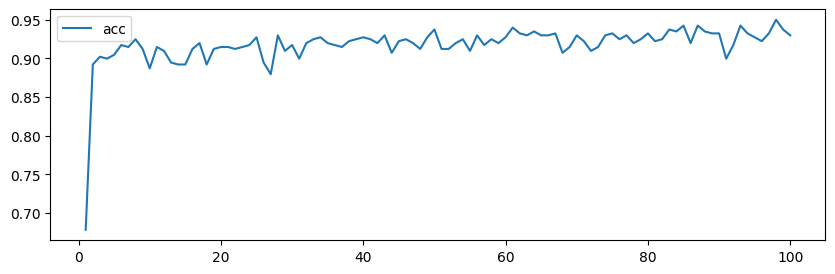

In [ ]:
# 학습 현황 출력
# 선그래프 시각화

# 그래프 도화지 사이트 설정
plt.figure(figsize=(10,3))
plt.plot(range(1,101),
    h.history['acc'], label='acc')
plt.legend()
plt.show()

In [ ]:
# 중간층 activation : 'sigmoid' -> 'relu'
# -- 크게 성능 개선이 되지은 않았지만, 기존보다는 반복횟수가 적을 때 빠르게 성능 개선
# 컴파일 optimizer : 'sgd' -> 'adam'
# -- 60% 성능이 90%이상으로 향상된 것을 확인
# -- 최적화함수: 선형 모델의 w,b에 대한 최적화
# -- 60% w,b 갱신(변화) 잘 못되고 있었음
# -- 90% w,b 갱신(변화, 최적화) 잘 되고 있는 상황

In [ ]:
# 모델 예측
# 모델 출력층 활성화함수를 거치고 나온 최종 결과값
# 시그모이드 : 0~1 (확률)
# 0.5 크면 1, 작으면 0
# 0.5 큰 확률 => 1 class 예측
pre = model.predict(X_test)
pre2 = pre > 0.5
pre2[:5]

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


array([[ True],
       [ True],
       [ True],
       [ True],
       [ True]])

In [ ]:
# 실제 0 예측 0 잘 예측 했을까?
# 실제 1 예측 1 잘 예측 했을까?
# 혼동 행렬표를 통해서 확인해보자
# sklearn 모듈 내에서 import
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, pre2)
cm = pd.DataFrame(cm, index=['실제0', '실제1'],
                  columns=['예측0', '예측1'])
cm

# 실제 0인 것을 예측 1이라고 잘못 판단한 것: 62개
# 실제 1인 것을 예측 1이라고 잘 판단한 것: 109개
# 현재 모델의 성능이 좋지 않은 상황
# 개선하기 위한 여러가지 노력이 필요
# 1. 모델 측면
# -- 모델 층 내용 재 설계, 재학습 : 중간층 개수, units 변경, 활성화함수
# -- 컴파일 : 최적화함수 변경
# 2. 데이터 측면

,예측0,예측1
실제0,0,62
실제1,0,109
